# Results Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_data

setup_plotting()
ensure_dirs()

In [2]:
# Load datasets
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')
questionnaires = pd.read_csv(PROCESSED_DIR / 'questionnaires_clean.csv')

# Ensure participant_id is string and padded
for df in [dataset_A, dataset_B, dataset_C, questionnaires]:
    df['participant_id'] = df['participant_id'].apply(lambda x: f"{int(x):03d}" if pd.notna(x) else np.nan)

# Find intersection (N=29)
p_A = set(dataset_A['participant_id'])
p_B = set(dataset_B['participant_id'])
p_C = set(dataset_C['participant_id'])
intersection = sorted(list(p_A & p_B & p_C))

print(f"Intersection size: {len(intersection)} participants")

# Filter datasets
df_A = dataset_A[dataset_A['participant_id'].isin(intersection)].sort_values('participant_id').reset_index(drop=True)
df_B = dataset_B[dataset_B['participant_id'].isin(intersection)].sort_values('participant_id').reset_index(drop=True)
df_C = dataset_C[dataset_C['participant_id'].isin(intersection)].sort_values('participant_id').reset_index(drop=True)

# Prepare features
X_A, y_A, _ = prepare_data(df_A, "Modality A")
X_B, y_B, _ = prepare_data(df_B, "Modality B")
X_C, y_C, _ = prepare_data(df_C, "Modality C")

y_target = y_A

Intersection size: 29 participants

Modality A: 29 samples, 1169 features

Modality B: 29 samples, 199 features

Modality C: 29 samples, 205 features


## Model Performance Comparison

/tmp/ipykernel_583274/1957588752.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_583274/1957588752.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_583274/1957588752.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')


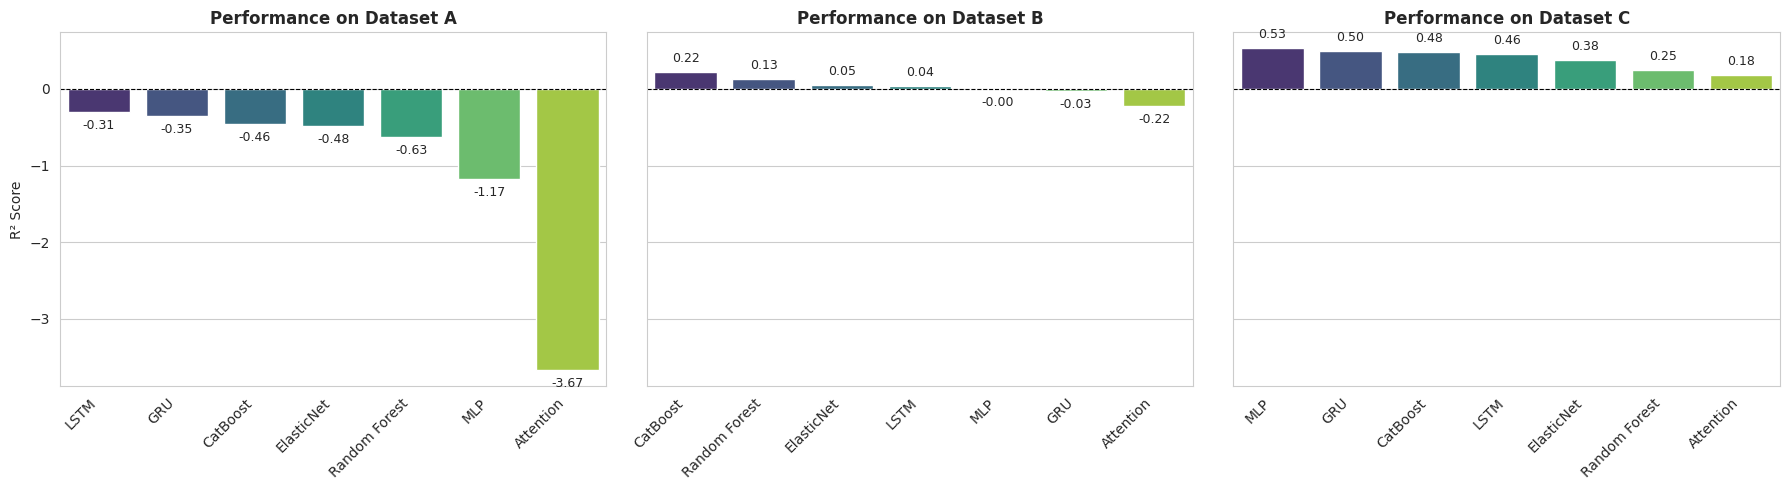

In [3]:
# Compare Model Performance across Datasets
import pickle

model_files = {
    'Random Forest': 'rf_results.pkl',
    'MLP': 'mlp_results.pkl',
    'CatBoost': 'cb_results.pkl',
    'ElasticNet': 'en_results.pkl',
    'LSTM': 'lstm_results.pkl',
    'GRU': 'gru_results.pkl',
    'Attention': 'attention_results.pkl'
}

results_data = []
for model_name, filename in model_files.items():
    filepath = RESULTS_DIR / filename
    if filepath.exists():
        with open(filepath, 'rb') as f:
            res = pickle.load(f)
            for ds_key in ['dataset_A', 'dataset_B', 'dataset_C']:
                if ds_key in res:
                    results_data.append({
                        'Model': model_name,
                        'Dataset': ds_key.replace('dataset_', 'Dataset '),
                        'R2': res[ds_key]['mean_r2']
                    })

df_res = pd.DataFrame(results_data)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
datasets = ['Dataset A', 'Dataset B', 'Dataset C']

for i, ds in enumerate(datasets):
    ds_data = df_res[df_res['Dataset'] == ds].sort_values('R2', ascending=False)
    if not ds_data.empty:
        sns.barplot(data=ds_data, x='Model', y='R2', ax=axes[i], hue='Model', palette='viridis', legend=False)
        axes[i].set_title(f'Performance on {ds}', fontweight='bold')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[i].set_ylabel('R² Score' if i == 0 else '')
        axes[i].set_xlabel('')
        
        # Add values on top of bars
        for p in axes[i].patches:
            val = p.get_height()
            axes[i].annotate(f"{val:.2f}", 
                             (p.get_x() + p.get_width() / 2., val), 
                             ha='center', va='bottom' if val > 0 else 'top', fontsize=9, 
                             xytext=(0, 5 if val > 0 else -5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [4]:
def get_oof_predictions(X_list, y, random_state=42):
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    n_modalities = len(X_list)
    n_samples = len(y)
    oof_preds = np.zeros((n_samples, n_modalities))
    
    cb_params = {
        'iterations': 1000,
        'depth': 3,
        'learning_rate': 0.05,
        'loss_function': "RMSE",
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1
    }
    
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(y)):
        for m_idx in range(n_modalities):
            X = X_list[m_idx]
            X_train, X_test = X[train_idx], X[test_idx]
            
            cb = CatBoostRegressor(**cb_params, random_seed=random_state + fold_idx)
            cb.fit(X_train, y[train_idx])
            oof_preds[test_idx, m_idx] = cb.predict(X_test)
    return oof_preds

# Get base predictions
X_list = [X_A, X_B, X_C]
oof_preds = get_oof_predictions(X_list, y_target)

# Run Stacking (Meta-learner)
stacker = CatBoostRegressor(iterations=200, depth=2, learning_rate=0.01, verbose=False, allow_writing_files=False, random_seed=42)
y_pred_stacked = cross_val_predict(stacker, oof_preds, y_target, cv=KFold(5, shuffle=True, random_state=42))

print("Predictions generated.")

Predictions generated.


In [5]:
# Create Error DataFrame
error_df = pd.DataFrame({
    'participant_id': intersection,
    'actual': y_target,
    'predicted': y_pred_stacked
})
error_df['residual'] = error_df['actual'] - error_df['predicted']
error_df['abs_error'] = error_df['residual'].abs()
error_df['sq_error'] = error_df['residual']**2

# Merge with metadata
meta_cols = ['participant_id', 'age', 'sex', 'group', 'WL_history', 'education', 'T2D']
error_df = error_df.merge(questionnaires[meta_cols], on='participant_id', how='left')

# Also add baseline BMI and weight from questionnaires
extra_meta = ['bmi1', 'weight1']
if all(c in questionnaires.columns for c in extra_meta):
    error_df = error_df.merge(questionnaires[['participant_id'] + extra_meta], on='participant_id', how='left')

error_df = error_df.sort_values('abs_error')
error_df.head()

,participant_id,actual,predicted,residual,abs_error,sq_error,age,sex,group,WL_history,education,T2D,bmi1,weight1
15,052,-0.658762,-0.456710,-0.202052,0.202052,0.040825,37,2,2,2.0,6,2,32.5,88.3
24,081,-0.118343,-0.362960,0.244617,0.244617,0.059837,52,2,2,2.0,6,2,36.0,96.9
10,034,3.280680,3.551421,-0.270741,0.270741,0.073301,45,2,2,2.0,6,2,35.2,89.6
22,074,1.893491,2.203742,-0.310251,0.310251,0.096256,55,2,2,2.0,8,2,35.3,97.4
13,048,-3.448276,-3.062051,-0.386225,0.386225,0.149170,55,2,2,2.0,6,2,33.3,76.3


In [6]:
top_n = 5
best_participants = error_df.nsmallest(top_n, 'abs_error')
worst_participants = error_df.nlargest(top_n, 'abs_error')

print(f"--- Best {top_n} Participants (Lowest Error) ---")
display(best_participants)

print(f"\n--- Worst {top_n} Participants (Highest Error) ---")
display(worst_participants)

--- Best 5 Participants (Lowest Error) ---


,participant_id,actual,predicted,residual,abs_error,sq_error,age,sex,group,WL_history,education,T2D,bmi1,weight1
15,052,-0.658762,-0.456710,-0.202052,0.202052,0.040825,37,2,2,2.0,6,2,32.5,88.3
24,081,-0.118343,-0.362960,0.244617,0.244617,0.059837,52,2,2,2.0,6,2,36.0,96.9
10,034,3.280680,3.551421,-0.270741,0.270741,0.073301,45,2,2,2.0,6,2,35.2,89.6
22,074,1.893491,2.203742,-0.310251,0.310251,0.096256,55,2,2,2.0,8,2,35.3,97.4
13,048,-3.448276,-3.062051,-0.386225,0.386225,0.149170,55,2,2,2.0,6,2,33.3,76.3



--- Worst 5 Participants (Highest Error) ---


,participant_id,actual,predicted,residual,abs_error,sq_error,age,sex,group,WL_history,education,T2D,bmi1,weight1
16,061,-11.297710,-2.687404,-8.610306,8.610306,74.137367,54,2,2,1.0,2,2,32.1,84.4
5,025,9.730363,2.564472,7.165891,7.165891,51.349995,38,2,2,2.0,4,2,35.3,84.7
2,012,-8.459870,-2.000804,-6.459066,6.459066,41.719530,40,2,2,2.0,6,2,39.2,117.1
4,024,-6.933744,-1.982448,-4.951296,4.951296,24.515334,52,2,1,1.0,6,2,30.7,80.2
1,007,5.533981,1.591464,3.942516,3.942516,15.543435,34,1,2,1.0,8,2,32.4,115.3


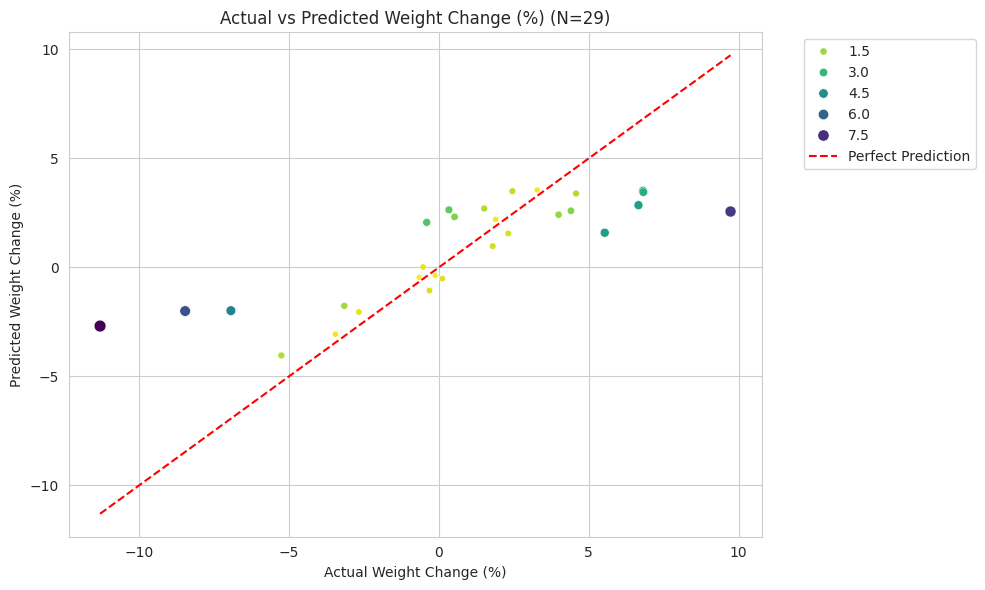

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=error_df, x='actual', y='predicted', hue='abs_error', size='abs_error', palette='viridis_r')
plt.plot([y_target.min(), y_target.max()], [y_target.min(), y_target.max()], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted Weight Change (%) (N=29)')
plt.xlabel('Actual Weight Change (%)')
plt.ylabel('Predicted Weight Change (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'error_analysis_scatter.png')
plt.show()

Mean values by Performance Group:


,age,bmi1,weight1,abs_error
performance_group,,,,
Best,48.8,34.46,89.70,0.282777
Worst,43.6,33.94,96.34,6.225815


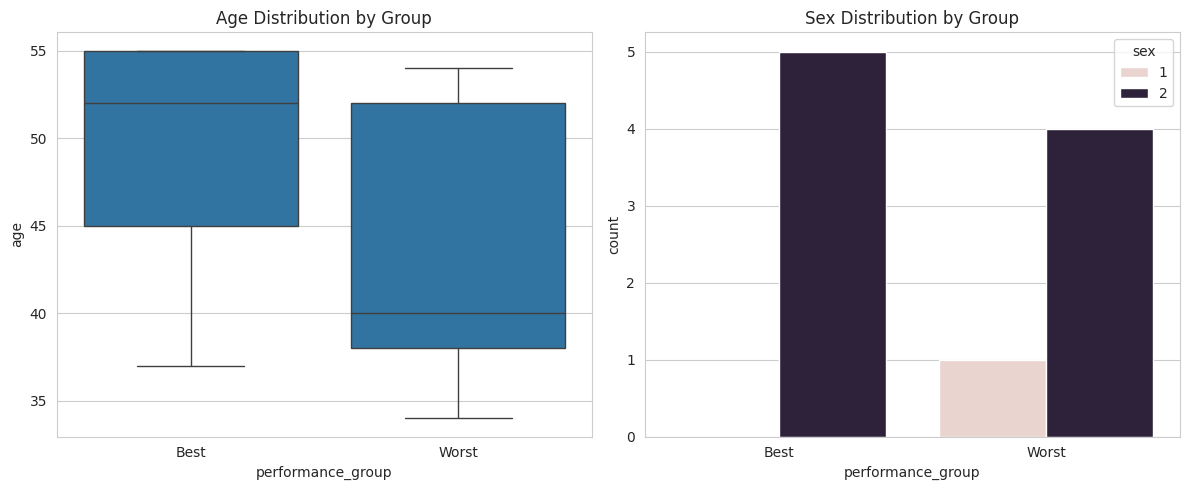

In [8]:
# Compare groups
error_df['performance_group'] = 'Middle'
error_df.loc[error_df['participant_id'].isin(best_participants['participant_id']), 'performance_group'] = 'Best'
error_df.loc[error_df['participant_id'].isin(worst_participants['participant_id']), 'performance_group'] = 'Worst'

comp_cols = ['age', 'bmi1', 'weight1', 'abs_error']
group_means = error_df[error_df['performance_group'] != 'Middle'].groupby('performance_group')[comp_cols].mean()

print("Mean values by Performance Group:")
display(group_means)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='performance_group', y='age', data=error_df[error_df['performance_group'] != 'Middle'])
plt.title('Age Distribution by Group')

plt.subplot(1, 2, 2)
sns.countplot(x='performance_group', hue='sex', data=error_df[error_df['performance_group'] != 'Middle'])
plt.title('Sex Distribution by Group')

plt.tight_layout()
plt.show()

In [ ]:
from src.utils.statistical_validation import main as run_statistical_validation
run_statistical_validation()
